In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

In [2]:
import os
dataset_path = "cell_images"
parasitized_path = os.path.join(dataset_path, "Parasitized")
uninfected_path = os.path.join(dataset_path, "Uninfected")
parasitized_images = os.listdir(parasitized_path)
uninfected_images = os.listdir(uninfected_path)

print(len(parasitized_images))
print(len(uninfected_images))

13780
13780


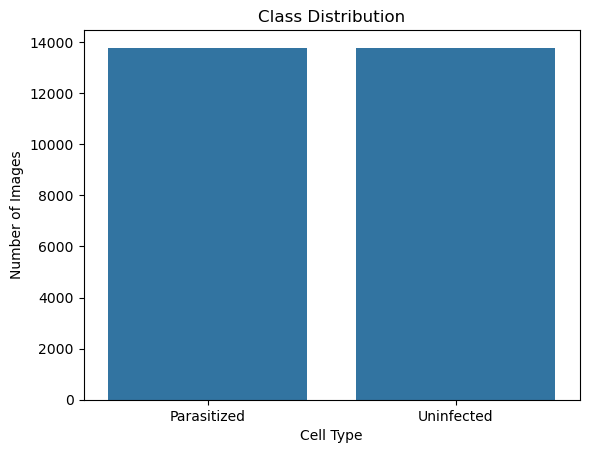

In [3]:
classes = ['Parasitized', 'Uninfected']
counts = [len(parasitized_images), len(uninfected_images)]
sns.barplot(x=classes, y=counts)
plt.title("Class Distribution")
plt.xlabel("Cell Type")
plt.ylabel("Number of Images")

plt.show()

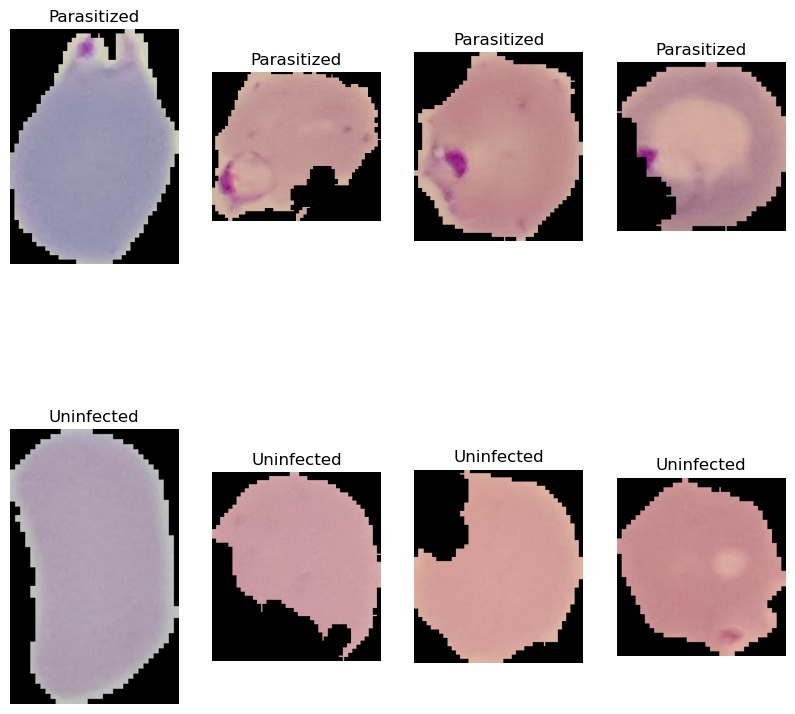

In [4]:
import cv2
import random
import os

plt.figure(figsize=(10,10))
for i in range(4):
    plt.subplot(2,4,i+1)
    img = cv2.imread(os.path.join(parasitized_path, random.choice(parasitized_images)))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title("Parasitized")
    plt.axis("off")

for i in range(4):
    plt.subplot(2,4,i+5)
    img = cv2.imread(os.path.join(uninfected_path, random.choice(uninfected_images)))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title("Uninfected")
    plt.axis("off")

plt.show()

In [5]:
data = []
labels = []
img_size = 128

for img in parasitized_images:
    img_path = os.path.join(parasitized_path, img)
    image = cv2.imread(img_path)
    if image is not None:
        image = cv2.resize(image, (img_size, img_size))
        data.append(image)
        labels.append(1)

for img in uninfected_images:
    img_path = os.path.join(uninfected_path, img)
    image = cv2.imread(img_path)
    if image is not None:
        image = cv2.resize(image, (img_size, img_size))
        data.append(image)
        labels.append(0)

data = np.array(data)
labels = np.array(labels)
print(data.shape)
print(labels.shape)

(27558, 128, 128, 3)
(27558,)


In [6]:
from sklearn.model_selection import train_test_split
X = data / 255.0
y = labels

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(22046, 128, 128, 3)
(5512, 128, 128, 3)
(22046,)
(5512,)


In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
cnn=Sequential()
cnn.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
cnn.add(MaxPooling2D())
cnn.add(Conv2D(64,(3,3),activation='relu'))
cnn.add(MaxPooling2D())
cnn.add(Conv2D(128,(3,3),activation='relu'))
cnn.add(MaxPooling2D())
cnn.add(Flatten())
cnn.add(Dense(128,activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(1,activation='sigmoid'))

cnn.compile(optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy'])

cnn.summary()

c:\Users\Soumya Goyal\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early=EarlyStopping(patience=5,restore_best_weights=True)

cnn_history=cnn.fit(
X_train,y_train,
validation_data=(X_val,y_val),
epochs=20,
batch_size=32,
callbacks=[early]
)

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 108s 154ms/step - accuracy: 0.8640 - loss: 0.3150 - val_accuracy: 0.9429 - val_loss: 0.1602
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 106s 154ms/step - accuracy: 0.9487 - loss: 0.1591 - val_accuracy: 0.9534 - val_loss: 0.1459
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.9554 - loss: 0.1374 - val_accuracy: 0.9565 - val_loss: 0.1338
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 102s 148ms/step - accuracy: 0.9599 - loss: 0.1219 - val_accuracy: 0.9539 - val_loss: 0.1436
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 99s 143ms/step - accuracy: 0.9620 - loss: 0.1075 - val_accuracy: 0.9510 - val_loss: 0.1575
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 101s 147ms/step - accuracy: 0.9668 - loss: 0.0984 - val_accuracy: 0.9561 - val_loss: 0.1351
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 146ms/step - accuracy: 0.9702 - loss: 0.0876 - val_accuracy: 0.9559 - val_loss: 0.1474
Epoch 8/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 94s 137ms/step - accuracy: 0.9734 - l

In [ ]:
base=MobileNetV2(weights='imagenet',include_top=False,input_shape=(128,128,3))
for layer in base.layers:
    layer.trainable=False
x=base.output
x=GlobalAveragePooling2D()(x)
x=Dense(128,activation='relu')(x)
x=Dropout(0.5)(x)
output=Dense(1,activation='sigmoid')(x)

mobilenet=Model(inputs=base.input,outputs=output)

mobilenet.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [11]:
mobilenet_history=mobilenet.fit(
X_train,y_train,
validation_data=(X_val,y_val),
epochs=20,
batch_size=32,
callbacks=[early]
)

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 65s 89ms/step - accuracy: 0.9032 - loss: 0.2467 - val_accuracy: 0.9298 - val_loss: 0.1857
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9273 - loss: 0.1933 - val_accuracy: 0.9387 - val_loss: 0.1698
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 64s 93ms/step - accuracy: 0.9326 - loss: 0.1838 - val_accuracy: 0.9378 - val_loss: 0.1618
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 67s 97ms/step - accuracy: 0.9327 - loss: 0.1795 - val_accuracy: 0.9374 - val_loss: 0.1625
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 68s 99ms/step - accuracy: 0.9366 - loss: 0.1746 - val_accuracy: 0.9298 - val_loss: 0.1802


In [12]:
base=EfficientNetB0(weights='imagenet',include_top=False,input_shape=(128,128,3))
for layer in base.layers:
    layer.trainable=False
x=base.output
x=GlobalAveragePooling2D()(x)
x=Dense(128,activation='relu')(x)
x=Dropout(0.5)(x)
output=Dense(1,activation='sigmoid')(x)

efficient=Model(inputs=base.input,outputs=output)
efficient.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


In [13]:
efficient_history=efficient.fit(
X_train,y_train,
validation_data=(X_val,y_val),
epochs=20,
batch_size=32,
callbacks=[early]
)

Epoch 1/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 112s 152ms/step - accuracy: 0.4976 - loss: 0.6955 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 99s 144ms/step - accuracy: 0.4995 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 130s 126ms/step - accuracy: 0.4966 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 89s 129ms/step - accuracy: 0.5001 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 92s 134ms/step - accuracy: 0.4981 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931


In [14]:
def plot_graphs(history,title):
    acc=history.history['accuracy']
    val_acc=history.history['val_accuracy']
    loss=history.history['loss']
    val_loss=history.history['val_loss']
    epochs=range(len(acc))
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs,acc,label='Train Accuracy')
    plt.plot(epochs,val_acc,label='Val Accuracy')
    plt.title(title+" Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs,loss,label='Train Loss')
    plt.plot(epochs,val_loss,label='Val Loss')
    plt.title(title+" Loss")
    plt.legend()

    plt.show()

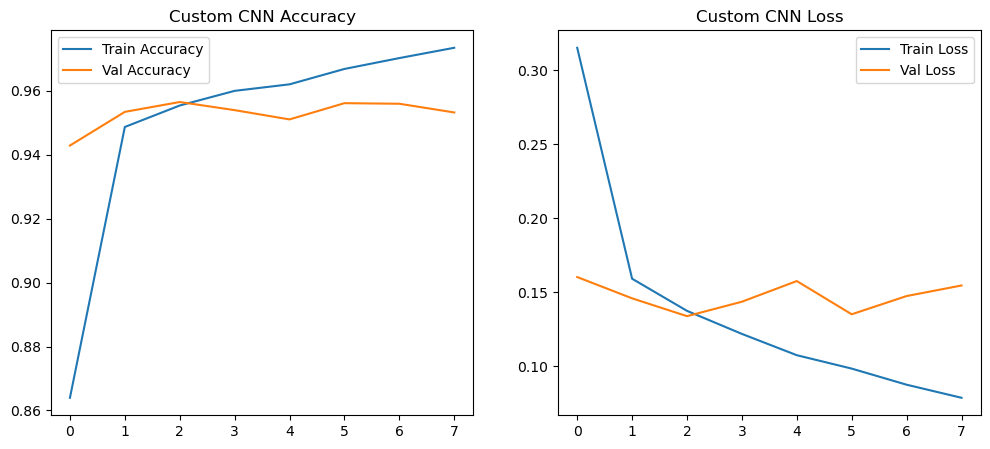

In [15]:
plot_graphs(cnn_history,"Custom CNN")

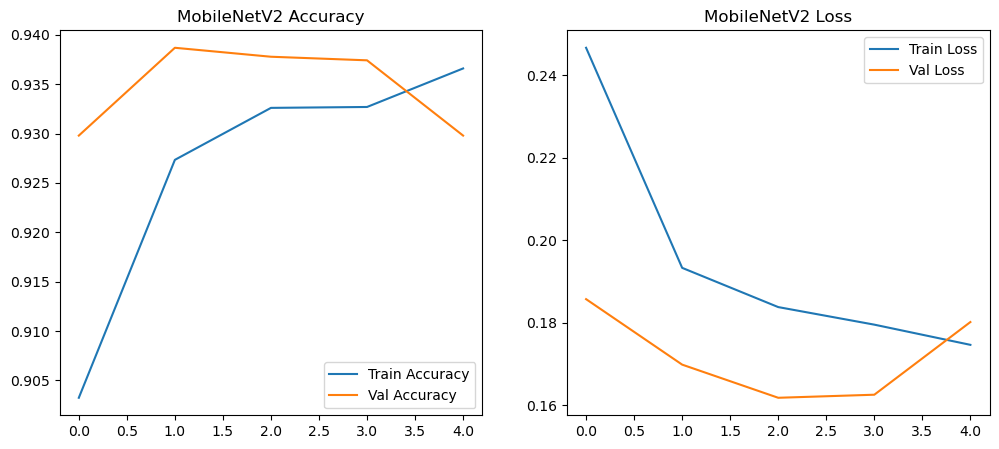

In [16]:
plot_graphs(mobilenet_history,"MobileNetV2")

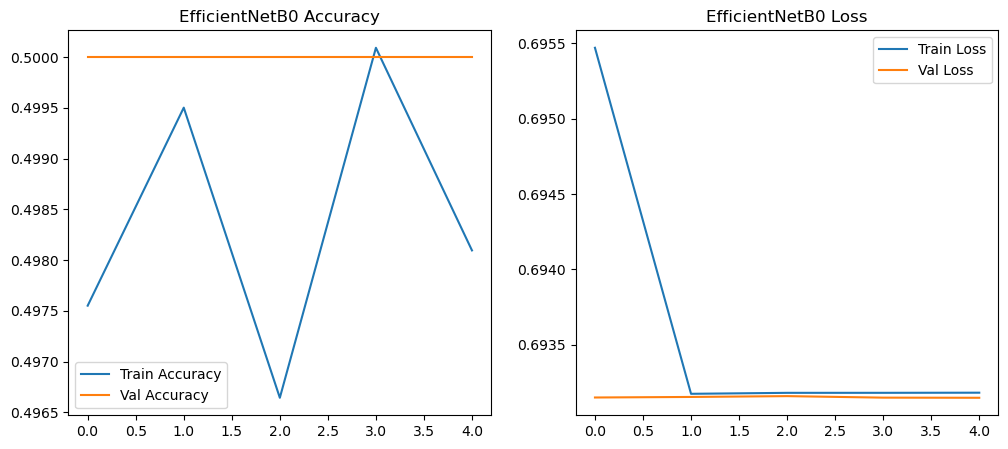

In [17]:
plot_graphs(efficient_history,"EfficientNetB0")

In [18]:
cnn_pred = (cnn.predict(X_val) > 0.5).astype("int32")
mobilenet_pred = (mobilenet.predict(X_val) > 0.5).astype("int32")
efficient_pred = (efficient.predict(X_val) > 0.5).astype("int32")

173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step
173/173 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step
173/173 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step


In [19]:
from sklearn.metrics import accuracy_score
cnn_acc = accuracy_score(y_val, cnn_pred)
mobilenet_acc = accuracy_score(y_val, mobilenet_pred)
efficient_acc = accuracy_score(y_val, efficient_pred)

print("Custom CNN Accuracy:", cnn_acc)
print("MobileNetV2 Accuracy:", mobilenet_acc)
print("EfficientNetB0 Accuracy:", efficient_acc)

Custom CNN Accuracy: 0.9564586357039188
MobileNetV2 Accuracy: 0.9297895500725689
EfficientNetB0 Accuracy: 0.5


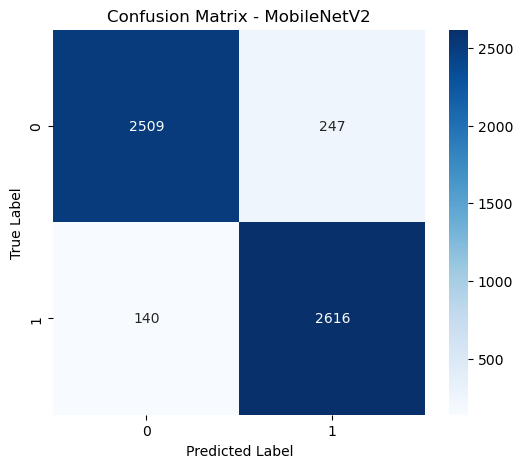

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val, mobilenet_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MobileNetV2")

plt.show()

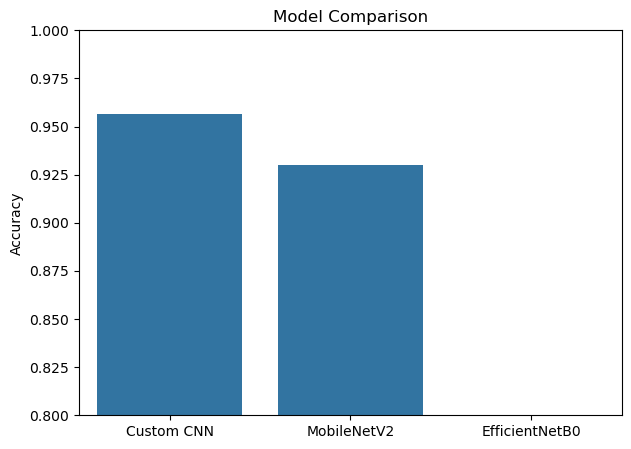

In [ ]:
models = ["Custom CNN","MobileNetV2","EfficientNetB0"]
accuracies = [cnn_acc, mobilenet_acc, efficient_acc]
plt.figure(figsize=(7,5))
sns.barplot(x=models, y=accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8,1.0)

plt.show()

In [22]:
mobilenet.save("best_malaria_model.h5")